<a href="https://colab.research.google.com/github/LuanaGoncalves177/Linguagem_Python_Colab/blob/main/python_etl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Desafio 2: Tratamento de dados com python

Aparência: Sol, Nublado, Chuva; ok
Temperatura: -130 a 130 F;
Umidade: 0 a 100;
Jogar: Sim ou não;
Tratamentos d NAs.
Obs: Imoportar o arquivo tempo.csv

In [ ]:
# 1. importar as bibliotecas
import pandas as pd
import seaborn as srn
import matplotlib.pyplot as plt # Adicionando import para pyplot
import statistics as sts

# 2. Importar o arquivo
dataset = pd.read_csv("tempo.csv", sep=";")
# 3. Visualizar
dataset.head() # Mostras as linha iniciaisda tabela

,Aparencia,Temperatura,Umidade,Vento,Jogar
0,sol,85,85.0,FALSO,nao
1,sol,80,90.0,VERDADEIRO,nao
2,nublado,83,86.0,FALSO,sim
3,chuva,70,NaN,FALSO,sim
4,chuva,68,80.0,FALSO,sim


In [ ]:

dataset.shape

(14, 5)

In [ ]:
dataset.dtypes

,0
Aparencia,object
Temperatura,int64
Umidade,float64
Vento,object
Jogar,object


2. Análise Exploratporias


1.   Dados Categóricos - preencher com a moda
2.   Dados Numéricos - preencher com a mediana



In [ ]:
#Explorar dados - Análise de Dados - Colunas Qualitativas
#Dados categóricos - estastitico e gráfico
#agrupar por Estados
agrupadoA = dataset.groupby(["Aparencia"]).size() # Agrupa por Estados
agrupadoA

,0
Aparencia,
chuva,5
menos,1
nublado,3
sol,5


<Axes: xlabel='Aparencia'>

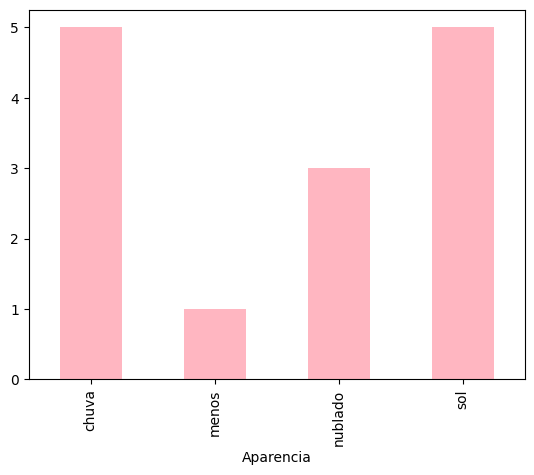

In [ ]:
agrupadoA.plot.bar( color ="lightpink") #Gráfico de dados com barras rosas

In [ ]:
agrupadoT = dataset.groupby(["Temperatura"]).size() # Agrupa por Estados
agrupadoT

,0
Temperatura,
64,1
65,1
68,1
69,1
70,1
71,1
72,1
75,2
80,1


<Axes: xlabel='Temperatura'>

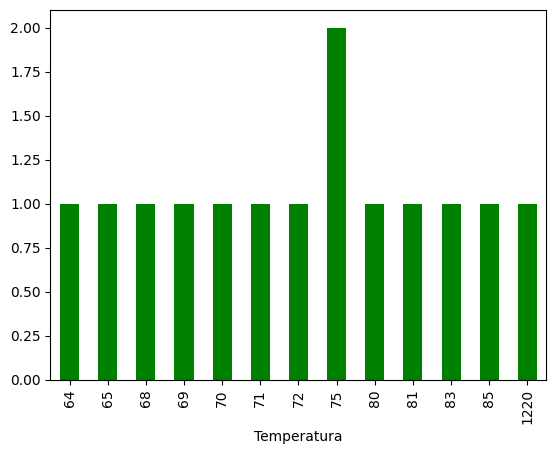

In [ ]:
agrupadoT.plot.bar( color ="Green") #Gráfico de dados com barras verdes

In [ ]:
agrupadoU = dataset.groupby(["Umidade"]).size() # Agrupa por Umidade
agrupadoU

,0
Umidade,
65.0,1
70.0,3
75.0,1
80.0,1
85.0,1
86.0,1
90.0,2
91.0,1
95.0,1


<Axes: xlabel='Umidade'>

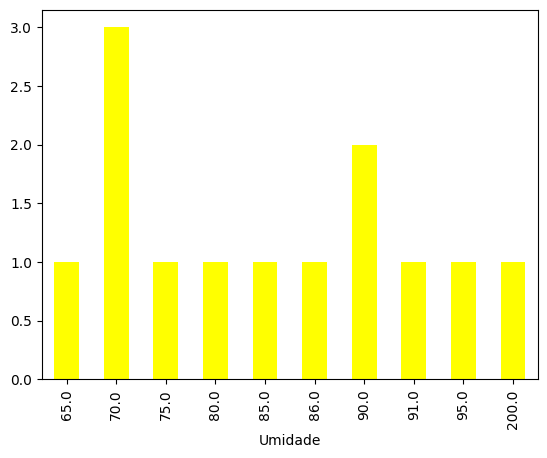

In [ ]:
agrupadoU.plot.bar( color ="Yellow") #Gráfico de dados com barras amarelas

In [ ]:
agrupadoV = dataset.groupby(["Vento"]).size() # Agrupa por Estados
agrupadoV

,0
Vento,
FALSO,7
VERDADEIRO,6


<Axes: xlabel='Vento'>

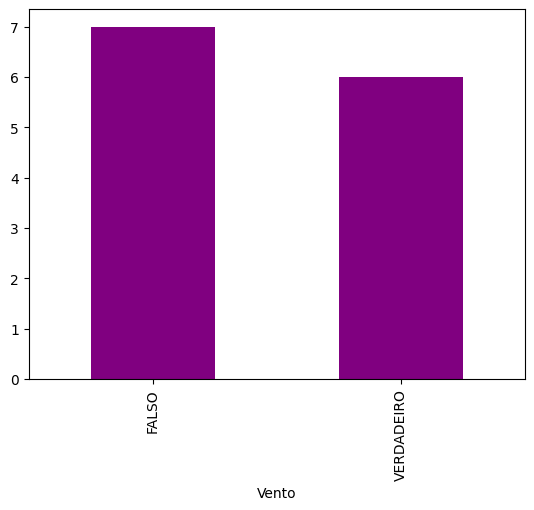

In [ ]:
agrupadoV.plot.bar( color ="Purple") #Gráfico de dados com barras roxas

In [ ]:
agrupadoJ = dataset.groupby(["Vento"]).size() # Agrupa por Estados
agrupadoJ

,0
Vento,
FALSO,7
VERDADEIRO,6


<Axes: xlabel='Vento'>

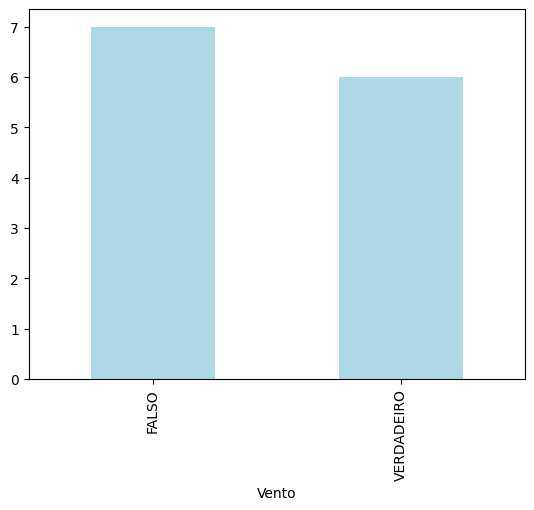

In [ ]:
agrupadoJ.plot.bar( color ="lightblue") #Gráfico de dados com barras azuis clara

In [ ]:
#Aparência: Sol, Nublado, Chuva;
dataset.loc[(dataset["Aparencia"] == "menos"), "Aparencia"] = "chuva"
agrupadoA = dataset.groupby(["Aparencia"]).size() # Agrupa por Estados
agrupadoA


,0
Aparencia,
chuva,6
nublado,3
sol,5


2. Tratamentos de dados

<Axes: xlabel='Aparencia'>

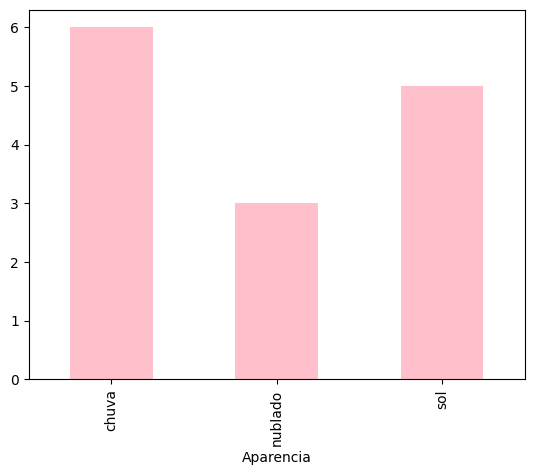

In [ ]:
#
agrupadoA.plot.bar( color ="pink") #Gráfico de dados com barras rosas

In [ ]:
#Temperatura: -130 a 130 F;
dataset.loc[(dataset["Temperatura"] < -130) | (dataset["Temperatura"] > 130), "Temperatura"] = sts.median(dataset["Temperatura"])
agrupadoT = dataset.groupby(["Temperatura"]).size() # Agrupa por Estados
agrupadoT

,0
Temperatura,
64.0,1
65.0,1
68.0,1
69.0,1
70.0,1
71.0,1
72.0,1
73.5,1
75.0,2


In [ ]:
# Calculo da mediana
mediana = sts.median(dataset["Temperatura"])
mediana

72.75

In [ ]:
dataset.loc[(dataset["Temperatura"] < -130) | (dataset["Temperatura"] > 130), "Temperatura"] = mediana
agrupadoT = dataset.groupby(["Temperatura"]).size() # Agrupa por Estados
agrupadoT

,0
Temperatura,
64.0,1
65.0,1
68.0,1
69.0,1
70.0,1
71.0,1
72.0,1
73.5,1
75.0,2


<Axes: xlabel='Temperatura'>

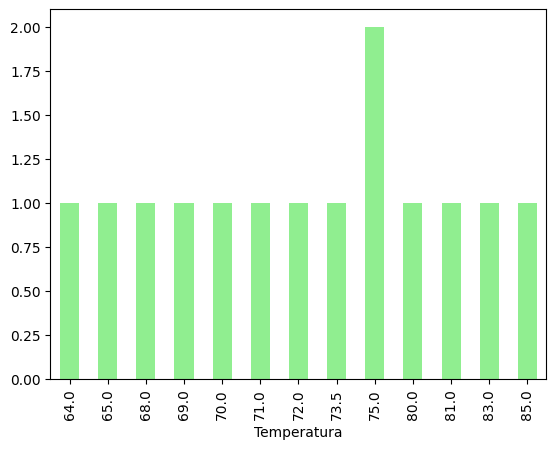

In [ ]:
agrupadoT.plot.bar( color ="lightGreen")

In [ ]:
#Umidade: 0 a 100:

In [ ]:
dataset.loc[(dataset["Umidade"] < 0) | (dataset["Umidade"] > 100), "Umidade"] = sts.median(dataset["Umidade"])
agrupadoU = dataset.groupby(["Umidade"]).size() # Agrupa por Umidade
agrupadoU

,0
Umidade,
65.0,1
70.0,3
75.0,1
80.0,1
85.0,1
85.5,1
86.0,1
90.0,2
91.0,1


In [ ]:
medianaU = sts.median(dataset["Umidade"])
medianaU

85.5

In [ ]:
dataset.loc[(dataset["Umidade"] < 0) | (dataset["Umidade"] > 100), "Umidade"] = medianaU
agrupadoU = dataset.groupby(["Umidade"]).size() # Agrupa por Umidade
agrupadoU

,0
Umidade,
65.0,1
70.0,3
75.0,1
80.0,1
85.0,1
85.5,1
86.0,1
90.0,2
91.0,1


<Axes: xlabel='Umidade'>

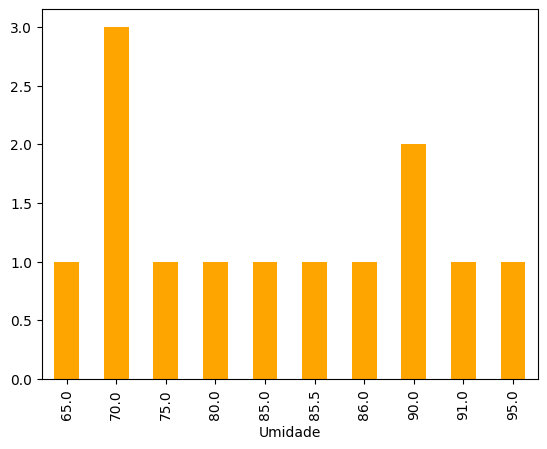

In [ ]:
agrupadoU.plot.bar( color ="orange") #Gráfico de dados com barras amarelas

In [ ]:
#Jogar: Sim ou não;
dataset.loc[(dataset["Jogar"] == "nao"), "Jogar"] = "não"
agrupadoJ = dataset.groupby(["Jogar"]).size() # Agrupa por Estados
agrupadoJ

,0
Jogar,
não,5
sim,9


<Axes: xlabel='Jogar'>

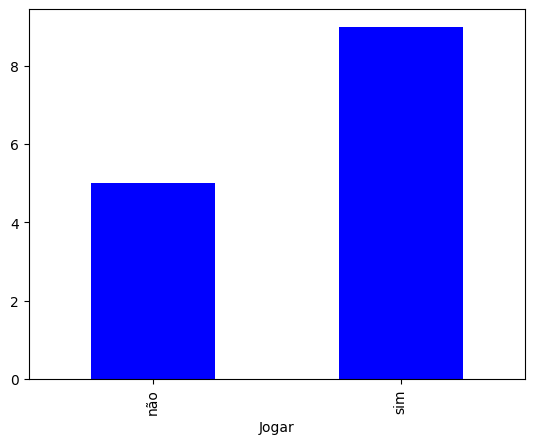

In [ ]:
agrupadoJ.plot.bar( color ="blue")

In [ ]:
#Tratamentos d NAs.
dataset.isnull().sum()

,0
Aparencia,0
Temperatura,0
Umidade,1
Vento,1
Jogar,0


In [ ]:
medianaU = dataset["Umidade"].median()
modoV = dataset["Vento"].mode()[0] # Calculate the mode for 'Vento' as it's categorical
dataset["Umidade"] = dataset["Umidade"].fillna(medianaU)
dataset["Vento"] = dataset["Vento"].fillna(modoV) # Fill with the mode

dataset['Umidade'].describe()

,Umidade
count,14.000000
mean,81.285714
std,9.585073
min,65.000000
25%,71.250000
50%,85.250000
75%,89.000000
max,95.000000


In [ ]:
agrupadoU = dataset.groupby(["Umidade"]).size() # Agrupa por Umidade
agrupadoU

,0
Umidade,
65.0,1
70.0,3
75.0,1
80.0,1
85.0,1
85.5,2
86.0,1
90.0,2
91.0,1


In [ ]:
dataset.isnull().sum()

,0
Aparencia,0
Temperatura,0
Umidade,0
Vento,0
Jogar,0


In [ ]:
agrupadoV = dataset.groupby(["Vento"]).size() # Agrupa por Estados
agrupadoV

,0
Vento,
FALSO,8
VERDADEIRO,6


<Axes: xlabel='Jogar'>

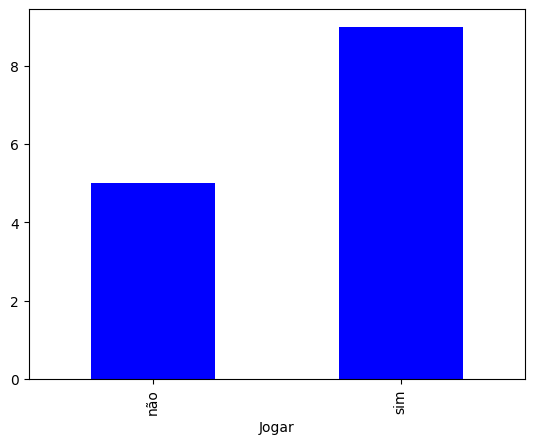

In [ ]:
agrupadoJ.plot.bar( color ="blue")

<Axes: xlabel='Vento'>

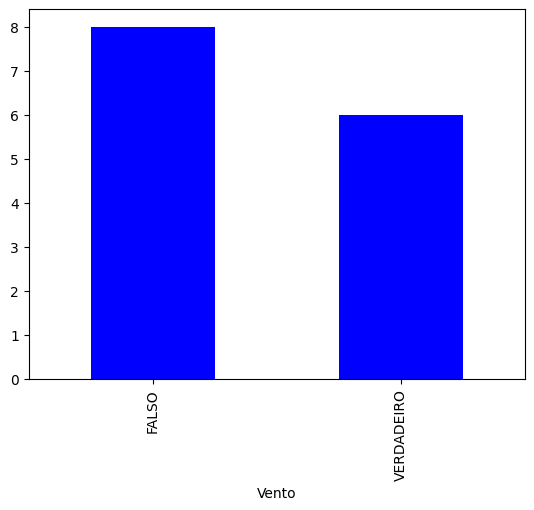

In [ ]:
agrupadoV.plot.bar( color ="blue")